## I. K-plus proche voisin (KNN) (Reconnaissance de chiffres) 

Le dataset **Digits** est une petite base d’images utilisée pour l’apprentissage automatique.
Elle contient :

✔ **1797 images**

✔ Chaque image représente **un chiffre écrit à la main** (0 → 9)

✔ Chaque image est de taille **8 × 8 pixels** (donc 64 valeurs)

---

#### **2. Que contient `digit` ?**

Quand tu fais :

```python
digit = load_digits()
```

Tu obtiens un dictionnaire contenant plusieurs informations, notamment :

* **digit['data']** → tableau de taille *(1797, 64)*
  → Chaque ligne représente une image "aplatit" en 64 valeurs (intensité des pixels en niveaux de gris)

* **digit['images']** → tableau *(1797, 8, 8)*
  → Chaque image sous forme de matrice 8×8 (comme une vraie petite image)

* **digit['target']** → vecteur *(1797,)*
  → le chiffre correspondant (0 → 9)



In [67]:
from sklearn.datasets import * 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier 
digit = load_digits() 
dig = pd.DataFrame(digit['data'][0:1700]) 
print(dig.head()) 
print(digit.keys())

    0    1    2     3     4     5    6    7    8    9   ...   54   55   56  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  5.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  9.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    57   58    59    60    61   62   63  
0  0.0  6.0  13.0  10.0   0.0  0.0  0.0  
1  0.0  0.0  11.0  16.0  10.0  0.0  0.0  
2  0.0  0.0   3.0  11.0  16.0  9.0  0.0  
3  0.0  7.0  13.0  13.0   9.0  0.0  0.0  
4  0.0  0.0   2.0  16.0   4.0  0.0  0.0  

[5 rows x 64 columns]
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


#### 3. Pourquoi 64 colonnes dans ton DataFrame ?


```python
dig = pd.DataFrame(digit['data'][0:1700])
```

* Tu prends les **1700 premières images**
* Tu les mets dans un DataFrame
* Comme chaque image = 8 × 8 = **64 pixels**, tu obtiens **64 colonnes** :

Colonne 0 → intensité du pixel 0

Colonne 1 → intensité du pixel 1
…
Colonne 63 → intensité du pixel 63

C’est une *image déroulée en une ligne*.

---

In [13]:
t = pd.DataFrame(digit['target'][0:1700]) 
print(t.head(20))

    0
0   0
1   1
2   2
3   3
4   4
5   5
6   6
7   7
8   8
9   9
10  0
11  1
12  2
13  3
14  4
15  5
16  6
17  7
18  8
19  9


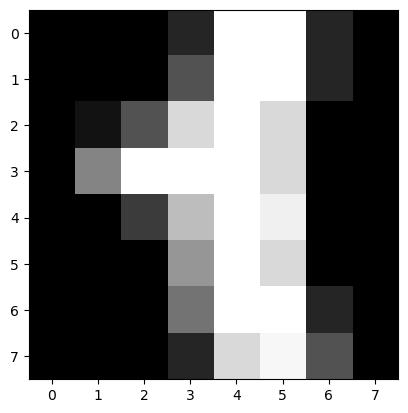

In [68]:
plt.imshow(digit['images'][21], cmap='Greys_r')
plt.show() 

* `digit['images'][i]` → renvoie la matrice 8×8 de l’image numéro *i*

* `cmap='Greys_r'` → affiche en niveaux de gris inversés (le blanc sur noir)

In [8]:
x = digit.data # input variables
y = digit.target # les étiquettes (output variable) 
#découpage du jeu de données (0.25 pour indiquer 25%) 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [9]:
### Train 
KNN = KNeighborsClassifier(7) # on utilise 7 voisins
KNN.fit(x_train, y_train) 

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
###Test 
print(KNN.score(x_test,y_test))

0.9866666666666667


#### Question 1 : Variez la valeur de k et étudiez la performance de KNN. 

In [11]:
scores = {}

for k in range(1, 21):  # k de 1 à 20
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    scores[k] = knn.score(x_test, y_test)

# Afficher les résultats
for k, acc in scores.items():
    print(f"k = {k} → accuracy = {acc:.4f}")


k = 1 → accuracy = 0.9867
k = 2 → accuracy = 0.9867
k = 3 → accuracy = 0.9844
k = 4 → accuracy = 0.9844
k = 5 → accuracy = 0.9867
k = 6 → accuracy = 0.9844
k = 7 → accuracy = 0.9867
k = 8 → accuracy = 0.9800
k = 9 → accuracy = 0.9800
k = 10 → accuracy = 0.9778
k = 11 → accuracy = 0.9778
k = 12 → accuracy = 0.9844
k = 13 → accuracy = 0.9800
k = 14 → accuracy = 0.9756
k = 15 → accuracy = 0.9711
k = 16 → accuracy = 0.9711
k = 17 → accuracy = 0.9689
k = 18 → accuracy = 0.9667
k = 19 → accuracy = 0.9644
k = 20 → accuracy = 0.9622


k = 1

Très bonne précision mais parfois trop sensible au bruit

Risque plus élevé de surapprentissage (overfitting)

✔ k entre 3 et 10

Souvent la zone où les performances sont les meilleures

Bon compromis : stable + précis

✔ k élevé (ex. > 15)

Le modèle devient plus "général"

Perte de précision : sous-apprentissage (underfitting)

## II. Bayésien Naïf (SPAM Filter) 

In [14]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']] 
df.columns = ['label', 'message'] 
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


#### Question  2 : Décrire  l'ensemble  de  données  « emails »  et  visualiser  le  nombre  de ham/spam. 

label
ham     4825
spam     747
Name: count, dtype: int64


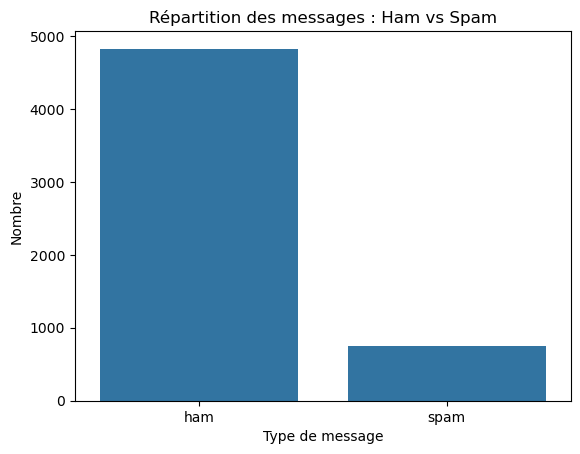

In [ ]:
# Comptage
count = df['label'].value_counts()

print(count)   

# Visualisation
sns.countplot(data=df, x='label')
plt.title("Répartition des messages : Ham vs Spam")
plt.xlabel("Type de message")
plt.ylabel("Nombre")
plt.show()

Pour nettoyer et normaliser le texte des emails, il faut : 

* Supprimer les ponctuations 

* Supprimer tous les mots vides 

* Appliquer  la  technique  de  « stemming »  (obtenir  la  forme  normale  du  mot).  Par exemple, « driving car» et « drives car» deviennent « drive car » 

In [16]:
import nltk 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/amira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
import string 
from nltk.corpus import stopwords #Natural Language Toolkit 
from nltk import PorterStemmer as Stemmer 
def process(text):     
    #lowercase it     
    text = text.lower() 
    # remove punctuation     
    text = ''.join([t for t in text if t not in string.punctuation]) 
    # remove stopwords     
    text = [t for t in text.split() if t not in stopwords.words('english')]     
    # stemming     
    st = Stemmer()     
    text = [st.stem(t) for t in text] 
    # return token list     
    return text 
# Testing 
print(process('It\'s holiday and we are playing cricket. Jeff is playing very well!!!')) 
# Test avec notre dataset
print(df['message'][1:5].apply(process)) 

['holiday', 'play', 'cricket', 'jeff', 'play', 'well']
1                         [ok, lar, joke, wif, u, oni]
2    [free, entri, 2, wkli, comp, win, fa, cup, fin...
3        [u, dun, say, earli, hor, u, c, alreadi, say]
4    [nah, dont, think, goe, usf, live, around, tho...
Name: message, dtype: object



#####  **1. `text.split()` :**

Divise la chaîne `text` en **liste de mots**.

Exemple :

```python
text = "Hello how are you"
text.split() → ["Hello", "how", "are", "you"]
```


#####  **2. List comprehension :**

```python
[t for t in ... if ...]
```

C’est une syntaxe rapide pour créer une nouvelle **liste**.

---



**objectif** : convertir chaque message (phrase) en vecteur de nombres parce que un algorithme (Naïve Bayes) ne comprend pas le texte.

La méthode utilisée = TF-IDF  → transforme chaque SMS en un tableau de nombres.

#### 1. Le vocabulaire : construire la liste de tous les mots

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidfv = TfidfVectorizer(analyzer=process)
data = tfidfv.fit_transform(df['message'])
print(data)



  (0, 3272)	0.13554044792902678
  (0, 4057)	0.3370037927640927
  (0, 5533)	0.2301133147049114
  (0, 2200)	0.26098623921116915
  (0, 1297)	0.25626412810936644
  (0, 1699)	0.2847021659551826
  (0, 4872)	0.18284951338255953
  (0, 3363)	0.18757162448436224
  (0, 7782)	0.22901968309377968
  (0, 4200)	0.2847021659551826
  (0, 2637)	0.1997662195999237
  (0, 1697)	0.32170654755913036
  (0, 1980)	0.2847021659551826
  (0, 3325)	0.15831816099050625
  (0, 1108)	0.3370037927640927
  (0, 7578)	0.18721401376124908
  (1, 5163)	0.27688324362563543
  (1, 4235)	0.41207318189732706
  (1, 4023)	0.46742635237301533
  (1, 7695)	0.4355907679554564
  (1, 7289)	0.2024772238069804
  (1, 5193)	0.5516408469094822
  (2, 3091)	0.11505037200973967
  (2, 2748)	0.3571909758763146
  (2, 413)	0.09987750376879972
  :	:
  (5568, 1325)	0.3853580960760783
  (5568, 8092)	0.35648782557862696
  (5568, 3080)	0.49107678037998326
  (5568, 2776)	0.5634467331174197
  (5569, 6762)	0.4714334480799934
  (5569, 4783)	0.4470332006149029



**✔ TfidfVectorizer(analyzer=process)**

TfidfVectorizer = convertit les messages en vecteurs TF-IDF

analyzer=process = chaque message passe par ta fonction process() (nettoyage, tokenisation, stopwords, etc.)

**✔ fit_transform(df['message'])**

* **fit** : construit le vocabulaire 

→ repère tous les mots **uniques** dans tout le dataset

→ calcule leur IDF

| Message             | Mots                 |
| ------------------- | -------------------- |
| "hello friend"      | hello, friend        |
| "hello how are you" | hello, how, are, you |

➡ Vocabulaire = [hello, friend, how, are, you]

Chaque mot reçoit un numéro (index) :

| Mot    | Index |
| ------ | ----- |
| hello  | 0     |
| friend | 1     |
| how    | 2     |
| are    | 3     |
| you    | 4     |

---

* **transform** : convertit chaque message en un vecteur :

une ligne = un message

une colonne = un mot du vocabulaire

contenu = valeur TF-IDF

➡ data devient une matrice creuse de taille
(N_messages × vocab_size)

`Prenons un message `:

"hello friend"


Il sera transformé en un vecteur :

index: 0   1   2   3   4

mots su vocabulaire : hello friend how are you

TF-IDF: X   Y   0    0   0


Tous les mots absents → 0

Les mots présents → une valeur **TF-IDF**

---

**RQ:** Une matrice TF-IDF contient **beaucoup de zéros.**

`Exemple` : vocabulaire de 10 000 mots.
Un message contient seulement 6 mots utiles → 6 valeurs ≠ 0.

Au lieu de stocker :[0, 0, 0, ..., 0.345, 0, 0.589, 0, ..., 0]

Scikit-Learn stocke **uniquement les valeurs non nulles** : 

(0, 540)    0.345

(0, 1123)   0.589

(0, 3500)   0.412

0 = numéro du document (message)

540 = index du mot dans le vocabulaire

0.345 = valeur TF-IDF

➡️ On économise énormément de mémoire.

#### Visualiser un message transformé :

In [22]:
mess = df.iloc[2]['message']
print(mess)
print(tfidfv.transform([mess]))


Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  (0, 72)	0.2330497030932461
  (0, 413)	0.09987750376879972
  (0, 420)	0.22518719340674634
  (0, 433)	0.22518719340674634
  (0, 833)	0.2190885570936267
  (0, 1180)	0.16669800498830506
  (0, 2076)	0.19516151371199045
  (0, 2246)	0.20302402339849024
  (0, 2748)	0.3571909758763146
  (0, 2868)	0.4660994061864922
  (0, 2969)	0.16669800498830506
  (0, 3091)	0.11505037200973967
  (0, 4592)	0.15903719770411495
  (0, 5768)	0.2330497030932461
  (0, 5815)	0.2330497030932461
  (0, 5856)	0.16027970945850903
  (0, 6959)	0.11759458460817876
  (0, 7099)	0.2190885570936267
  (0, 7276)	0.12336193745345178
  (0, 7708)	0.14471405235314777
  (0, 7741)	0.18906287739887084


(0, 72) → message n°0 , mot n°72 dans le vocabulaire

0.2133049 = sa valeur TF-IDF dans ce message

In [ ]:
#Convertir en tableau complet
j = tfidfv.transform([mess]).toarray()[0]

#Afficher les mots, leur idf, leur tfidf
print('index\tidf\ttfidf\tterm')
for i in range(len(j)):
    if j[i] != 0:
        print(i,
              format(tfidfv.idf_[i], '.4f'),
              format(j[i], '.4f'),
              tfidfv.get_feature_names_out()[i],
              sep='\t')


index	idf	tfidf	term
72	8.5271	0.2330	08452810075over18
413	3.6544	0.0999	2
420	8.2394	0.2252	2005
433	8.2394	0.2252	21st
833	8.0163	0.2191	87121
1180	6.0993	0.1667	appli
2076	7.1408	0.1952	comp
2246	7.4285	0.2030	cup
2748	6.5346	0.3572	entri
2868	8.5271	0.4661	fa
2969	6.0993	0.1667	final
3091	4.2096	0.1151	free
4592	5.8190	0.1590	may
5768	8.5271	0.2330	questionstd
5815	8.5271	0.2330	ratetc
5856	5.8645	0.1603	receiv
6959	4.3027	0.1176	text
7099	8.0163	0.2191	tkt
7276	4.5137	0.1234	txt
7708	5.2950	0.1447	win
7741	6.9176	0.1891	wkli


#### 1. `tfidfv.transform([mess])`

Cette instruction transforme ton message en **vecteur TF-IDF sparse**.

C’est une matrice *sparse* (creuse), par exemple :

```
(0, 540)   0.4472
(0, 1123)  0.2985
...
```

C'est une matrice CSR (Compressed Sparse Row), **pas un tableau normal**.

---

#### 2. `.toarray()`

Cette fonction convertit la matrice sparse en **tableau NumPy 2D classique**.

Exemple :

```
[[0.0, 0.0, 0.4472, 0.0, 0.2985, ...]]
```

C’est maintenant une vraie matrice 2D de dimension :

```
1 × vocabulaire_size
```

C’est-à-dire : **un tableau contenant toutes les colonnes du vecteur TF-IDF**.

---

#### 3. `[0]`

`[0]` signifie : « prends la première (et seule) ligne ».

Comme tu as transformé **un seul message**, la matrice contient **juste une ligne**, donc :

```
toarray() = [[0.0, 0.1, 0.0, 0.5, ...]]
```

Alors :

```
toarray()[0] = [0.0, 0.1, 0.0, 0.5, ...]
```

➡️ un **vecteur 1D** représentant ton message.

---



### Différence entre TF, IDF et TF-IDF
`✔ TF = Term Frequency`: **Fréquence** du mot dans le message.

*TF = (nombre d’occurrences du mot dans le document) / (nombre total de mots)*

Exemple :
message : "hello hello world"

TF(hello) = 2/3

`✔ IDF = Inverse Document Frequency`: Mesure si un mot est **rare** ou fréquent dans tout le corpus.

*IDF = log( N / df )*

N = nombre total de documents

df = nombre de documents où le mot apparaît


Un mot rare → IDF élevé

Un mot fréquent (ex : "the", "a") → IDF faible

👉 IDF pénalise les mots trop courants.

`✔ TF-IDF = TF × IDF`: C’est le **poids final** du mot dans le document :

*TF-IDF = TF * IDF*


Interprétation :

haut TF → mot fréquent dans ce message

haut IDF → mot rare dans le corpus

donc haut TF-IDF = mot important dans ce message

In [26]:
from sklearn.pipeline import Pipeline 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.model_selection import train_test_split 
spam_filter = Pipeline([
    ('vectorizer', TfidfVectorizer(analyzer=process)),
    ('classifier', MultinomialNB())
])


Le Pipeline fait 2 choses automatiquement :

**1) Convertir le texte → vecteurs TF-IDF**

Grâce à : **TfidfVectorizer(analyzer=process)**


Il transforme chaque message en une grande ligne contenant les poids TF-IDF des mots.

**2) Apprendre un modèle Naïve Bayes**

Avec : **MultinomialNB()**


C’est un modèle spécialement conçu pour les données textuelles, basé sur le théorème de Bayes.

🧠 Pourquoi Naïve Bayes marche bien pour les spams ?

Parce qu’il estime :

* quelles sont les probabilités qu’un mot apparaisse dans un spam

* quelles sont les probabilités qu’un mot apparaisse dans un ham

Puis il applique le théorème de Bayes pour classer un mail.

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    df['message'], 
    df['label'], 
    test_size=0.20, 
    random_state=21
)


In [28]:
spam_filter.fit(x_train, y_train)


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [29]:
predictions = spam_filter.predict(x_test)


In [30]:
count = 0
for i in range(len(y_test)):
    if y_test.iloc[i] != predictions[i]:
        count += 1


In [31]:
print('Total number of test cases', len(y_test))
print('Number of wrong predictions', count)


Total number of test cases 1115
Number of wrong predictions 39


b) Visualisez les prédictions erronées qui ont été classées comme du ham ? 

In [32]:
# Convertir predictions en Series pour faciliter la comparaison
pred_series = pd.Series(predictions, index=y_test.index)

# Sélection des faux négatifs (spam classé comme ham)
false_negatives = x_test[(y_test == 'spam') & (pred_series == 'ham')]

print("Nombre de spams classés comme ham :", len(false_negatives))
print("\nExemples de messages :\n")

# Afficher quelques exemples
for msg in false_negatives.head(10):
    print("----")
    print(msg)


Nombre de spams classés comme ham : 39

Exemples de messages :

----
Send a logo 2 ur lover - 2 names joined by a heart. Txt LOVE NAME1 NAME2 MOBNO eg LOVE ADAM EVE 07123456789 to 87077 Yahoo! POBox36504W45WQ TxtNO 4 no ads 150p
----
sexy sexy cum and text me im wet and warm and ready for some porn! u up for some fun? THIS MSG IS FREE RECD MSGS 150P INC VAT 2 CANCEL TEXT STOP
----
Twinks, bears, scallies, skins and jocks are calling now. Don't miss the weekend's fun. Call 08712466669 at 10p/min. 2 stop texts call 08712460324(nat rate)
----
Hey Boys. Want hot XXX pics sent direct 2 ur phone? Txt PORN to 69855, 24Hrs free and then just 50p per day. To stop text STOPBCM SF WC1N3XX
----
YES! The only place in town to meet exciting adult singles is now in the UK. Txt CHAT to 86688 now! 150p/Msg.
----
SMS. ac JSco: Energy is high, but u may not know where 2channel it. 2day ur leadership skills r strong. Psychic? Reply ANS w/question. End? Reply END JSCO
----
LIFE has never been this much fun

In [33]:
message_test = "Your cash-balance is currently 500 pounds - to maximize your cash-in now, send COLLECT to 83600."
prediction = spam_filter.predict([message_test])
print("Classe prédite :", prediction[0])


Classe prédite : spam


In [34]:
#Calculez Rappel  Précision F1 score 
from sklearn.metrics import classification_report 
print(classification_report(predictions, y_test)) 

              precision    recall  f1-score   support

         ham       1.00      0.96      0.98      1014
        spam       0.72      1.00      0.84       101

    accuracy                           0.97      1115
   macro avg       0.86      0.98      0.91      1115
weighted avg       0.97      0.97      0.97      1115



## III. Régression Linéaire (Prédiction du gain) 

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy import stats 
df = pd.read_csv("univariateLinearRegression.csv",header=None) 
print(len(df))


97


In [11]:
#selection de la première colonne de la base (la taille de la population) 
X = df.iloc[0:len(df),0] 
#selection de la deuxième colonne de la base (le profit effectué) 
Y = df.iloc[0:len(df),1]

In [12]:
print(X.head())

0    6.1101
1    5.5277
2    8.5186
3    7.0032
4    5.8598
Name: 0, dtype: float64


#### Question 4 : Visualiser les données avec un scatter plot. Interprétez le résultat. 

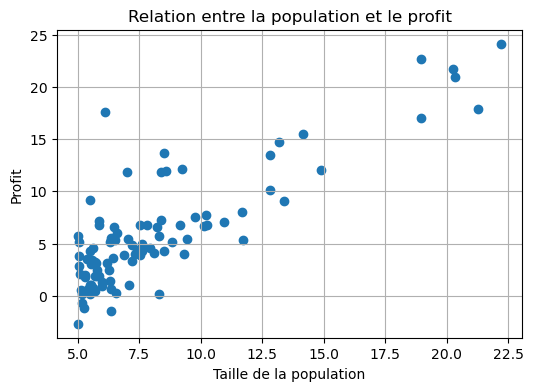

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(X, Y)
plt.xlabel("Taille de la population")
plt.ylabel("Profit")
plt.title("Relation entre la population et le profit")
plt.grid(True)
plt.show()


Le nuage de points montre une **relation linéaire** positive entre la taille de la population et le profit. 

Malgré une certaine dispersion des données, la tendance croissante est nette, ce qui justifie l’utilisation d’un modèle de **régression linéaire** pour prédire le profit à partir de la population.

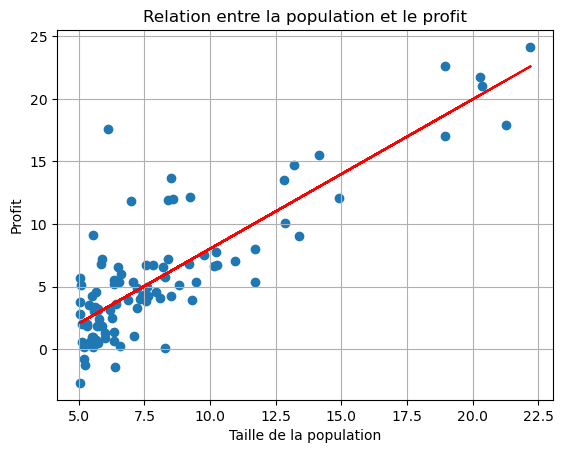

In [15]:
#linregress() renvoie plusieurs variables de retour. On s'interesse au slope et intercept 
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y) 
def F(x):
    return slope * x + intercept 
#la variable fitLine est un tableau de valeurs prédites depuis la tableau de variables X 
fitLine = F(X) 
plt.scatter(X,Y) 
plt.plot(X, fitLine, c='r') 
plt.xlabel("Taille de la population")
plt.ylabel("Profit")
plt.title("Relation entre la population et le profit")
plt.grid(True)
plt.show()


In [16]:
print (F(20.27)) 

20.28701108941122


## IIII. Régression multivariée (Prédiction du prix) 

In [18]:
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 854.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 868.5 kB/s eta 0:00:00a 0:00:01


In [30]:
!pip install openpyxl


14219.85s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable


In [22]:
import pandas as pd 
import statsmodels.api as sm 
from sklearn.preprocessing import StandardScaler 
import numpy as np 
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.pyplot as plt 
df = pd.read_excel("MultivariateLinearRegression.xlsx") 
print(df.head())

   taille_en_pieds_carre  nb_chambres    prix
0                   2104            3  399900
1                   1600            3  329900
2                   2400            3  369000
3                   1416            2  232000
4                   3000            4  539900


In [23]:
#Récupérer le prix : les valeurs observées pour la variable Cible 
Y = df["prix"] 
#Récupérer les variables prédictives : La superficie en pieds² et le nb chambre 
X = df[['taille_en_pieds_carre','nb_chambres']] 

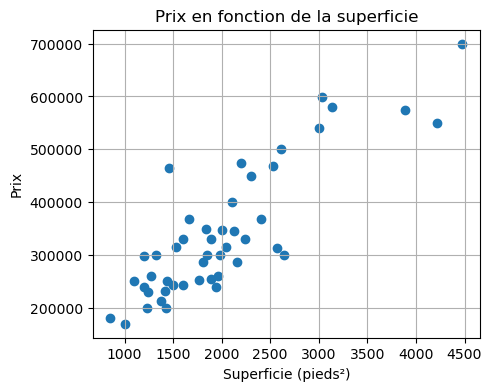

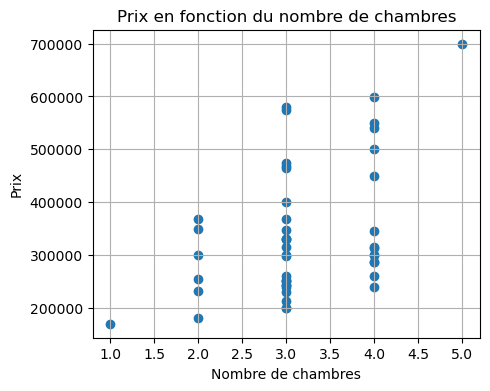

In [25]:
plt.figure(figsize=(5,4))
plt.scatter(df['taille_en_pieds_carre'], df['prix'])
plt.xlabel("Superficie (pieds²)")
plt.ylabel("Prix")
plt.title("Prix en fonction de la superficie")
plt.grid(True)
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(df['nb_chambres'], df['prix'])
plt.xlabel("Nombre de chambres")
plt.ylabel("Prix")
plt.title("Prix en fonction du nombre de chambres")
plt.grid(True)
plt.show()



* Prix vs Superficie

On observe une relation croissante :
plus la superficie augmente, plus le prix augmente.
--> Forte corrélation positive.

* Prix vs Nombre de chambres

Le prix tend à augmenter avec le nombre de chambres,
mais la relation est moins régulière que celle avec la superficie.

In [27]:
scale = StandardScaler() 
X_scaled = scale.fit_transform(X[['taille_en_pieds_carre', 'nb_chambres']].to_numpy()) 
print(X_scaled)

[[ 1.31415422e-01 -2.26093368e-01]
 [-5.09640698e-01 -2.26093368e-01]
 [ 5.07908699e-01 -2.26093368e-01]
 [-7.43677059e-01 -1.55439190e+00]
 [ 1.27107075e+00  1.10220517e+00]
 [-1.99450507e-02  1.10220517e+00]
 [-5.93588523e-01 -2.26093368e-01]
 [-7.29685755e-01 -2.26093368e-01]
 [-7.89466782e-01 -2.26093368e-01]
 [-6.44465993e-01 -2.26093368e-01]
 [-7.71822042e-02  1.10220517e+00]
 [-8.65999486e-04 -2.26093368e-01]
 [-1.40779041e-01 -2.26093368e-01]
 [ 3.15099326e+00  2.43050370e+00]
 [-9.31923697e-01 -2.26093368e-01]
 [ 3.80715024e-01  1.10220517e+00]
 [-8.65782986e-01 -1.55439190e+00]
 [-9.72625673e-01 -2.26093368e-01]
 [ 7.73743478e-01  1.10220517e+00]
 [ 1.31050078e+00  1.10220517e+00]
 [-2.97227261e-01 -2.26093368e-01]
 [-1.43322915e-01 -1.55439190e+00]
 [-5.04552951e-01 -2.26093368e-01]
 [-4.91995958e-02  1.10220517e+00]
 [ 2.40309445e+00 -2.26093368e-01]
 [-1.14560907e+00 -2.26093368e-01]
 [-6.90255715e-01 -2.26093368e-01]
 [ 6.68172729e-01 -2.26093368e-01]
 [ 2.53521350e-01 -2

In [28]:
model = sm.OLS(Y, X).fit() 
print(model.summary()) 

                                 OLS Regression Results                                
Dep. Variable:                   prix   R-squared (uncentered):                   0.966
Model:                            OLS   Adj. R-squared (uncentered):              0.964
Method:                 Least Squares   F-statistic:                              631.4
Date:                Sun, 14 Dec 2025   Prob (F-statistic):                    1.19e-33
Time:                        20:14:02   Log-Likelihood:                         -589.11
No. Observations:                  47   AIC:                                      1182.
Df Residuals:                      45   BIC:                                      1186.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

Pour tester notre modèle, on va lui fournir la taille de la maison et le nombre chambre. 

In [29]:
def predict_price_of_house(taille_maison, nb_chambre):     
    return 140.8611 * taille_maison + 1.698e+04 * nb_chambre 


print(predict_price_of_house(4500,5))

718774.95


prix_estimé = F(superficie, nb_chambres) = ε + α * superficie + β * nb_chambres 

| Critère             | Univariée (`linregress`) | Multivariée (`OLS`)   |
| ------------------- | ------------------------ | ------------------- |
| Nb de variables X   | 1                        | ≥ 2                 |
| Forme du modèle     | Droite                   | Plan / hyperplan    |
| Méthode             | Formule directe          | Algèbre matricielle |
| Précision           | Limitée                  | Plus réaliste       |
| Analyse statistique | Basique                  | Complète            |


## IIIIII. Régression polynomiale (Prédiction du salaire) 

### 1️⃣ Qu’est-ce que la régression polynomiale ?

La **régression polynomiale** est une extension de la régression linéaire.

* Alors que la **régression linéaire** essaie de trouver une relation linéaire entre la variable indépendante (x) et la variable dépendante (y) :
  
  ## y = b + a x
  
* La **régression polynomiale** permet de modéliser des relations **non linéaires** en ajoutant des puissances de (x) :
  
  ## y = a0 + a1 x + a2 x^2 + a3 x^3 + ... + ad x^d
  
  où (d) est le **degré du polynôme**.

En gros : on transforme la variable (x) pour créer de nouvelles caractéristiques comme (x^2, x^3,...), et ensuite on applique une régression linéaire classique sur ces nouvelles caractéristiques.

---

### 2️⃣ Comment l’algorithme fonctionne

1. **Choisir le degré du polynôme** (d) : plus (d) est grand, plus le modèle peut s’adapter aux variations des données (attention au surapprentissage).
2. **Transformer les données** : `créer de nouvelles colonnes pour (x^2, x^3, ..., x^d).`
3. **Appliquer une régression linéaire** sur ces colonnes. L’algorithme va estimer les coefficients (a0, a1, ... , ad) en minimisant l’erreur (souvent l’erreur quadratique moyenne).
4. **Faire des prédictions** : pour une nouvelle valeur de (x), le modèle calcule
   
   ## y_predit = a0 + a1 x + a2 x^2 + ... + ad x^d
   



Nous allons utiliser les données de salaire des employés. Dans cet ensemble de données, nous  avons  trois  colonnes :  Position,  Level  and  Salary.  On  commence  par  charger  les données contenues dans le fichier Excel.  

In [38]:
# Importez les libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
df_sal = pd.read_csv('Position_Salaries.csv') 
df_sal.head() 

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


#### Question 6: Visualisez  la distribution  des  données  avec  Seaborn  plot.

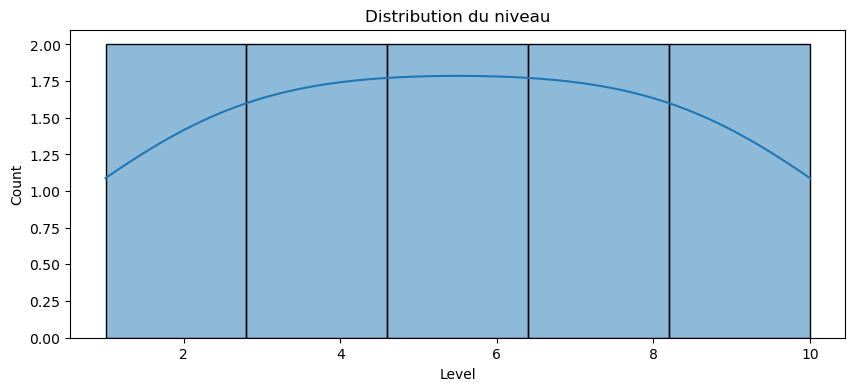

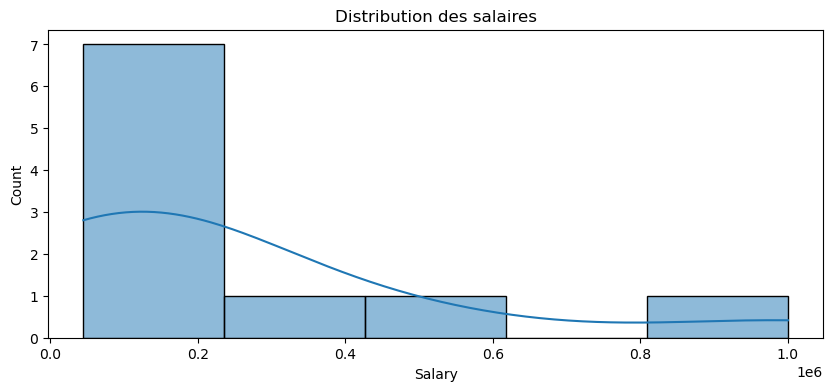

In [39]:
plt.figure(figsize=(10,4))
sns.histplot(df_sal['Level'], kde=True)
plt.title("Distribution du niveau")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_sal['Salary'], kde=True)
plt.title("Distribution des salaires")
plt.show()


Dressez  un  scatter  plot  pour  examiner  la relation entre le salaire et le niveau. Interprétez le résultat

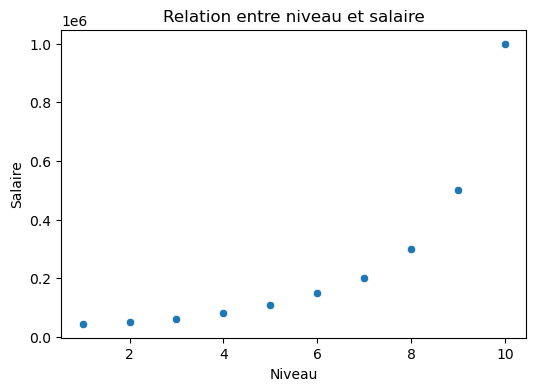

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_sal, x='Level', y='Salary')
plt.title("Relation entre niveau et salaire")
plt.xlabel("Niveau")
plt.ylabel("Salaire")
plt.show()


Divisez  l'ensemble  de  données  en  variables  dépendantes/indépendantes :  L'expérience (X) est une variable indépendante ; le salaire (y) dépend de l'expérience.

In [41]:
X = df_sal.iloc[:, 1:-1].values   # Level
y = df_sal.iloc[:, -1].values     # Salary


In [42]:
lr = LinearRegression()
lr.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
pr = PolynomialFeatures(degree=4)
X_poly = pr.fit_transform(X)

lr_2 = LinearRegression()
lr_2.fit(X_poly, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False



Tu veux prédire un **salaire** en fonction du **Level**.

Mais la relation n’est **pas linéaire**, donc tu vas transformer X pour que le modèle puisse tracer une **courbe**, pas une ligne droite.


 #### **1) X = df_sal.iloc[:, 1:-1].values**

👉  **On extrait la colonne Level**

Ton tableau original (df_sal) ressemble à ceci :

| Position | Level | Salary |
| -------- | ----- | ------ |

* Colonne index 0 → Position
* Colonne index 1 → **Level**
* Colonne index 2 → Salary

`1:-1` signifie :
➡️ prendre uniquement la colonne 1(-1 cad derniére colonne est exclue)


Donc X devient :

```
[[1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10]]
```

C’est un **tableau 2D** contenant uniquement le niveau.

---

 #### **2) pr = PolynomialFeatures(degree=4)**

👉 **On prépare une machine qui va fabriquer : X, X², X³, X⁴**

Tu dis :

> “Je veux transformer Level en plusieurs versions de lui-même : puissance 1, puissance 2, puissance 3, puissance 4.”

C’est tout.

---

 #### **3) X_poly = pr.fit_transform(X)**

👉 **On transforme réellement X en un tableau plus grand**

Ton X contenait par exemple :

```
Level = 1
```

La machine produit :

```
[1, 1, 1², 1³, 1⁴] = [1, 1, 1, 1, 1]
```

Si Level = 2 :

```
[1, 2, 4, 8, 16]
```

Si Level = 3 :

```
[1, 3, 9, 27, 81]
```

Donc X_poly devient :

```
[
 [1, 1,   1,    1,     1],
 [1, 2,   4,    8,    16],
 [1, 3,   9,   27,    81],
 ...
 [1, 10, 100, 1000, 10000]
]
```

➡️ **Ton X a maintenant 5 colonnes au lieu d’1.**
➡️ Grâce à ces colonnes, le modèle peut tracer une courbe.

---

#### **4) lr_2 = LinearRegression()**`

👉 On crée un modèle de régression linéaire.

Mais attention :
La régression linéaire signifie :
« je cherche une combinaison des colonnes »

Pas forcément une droite !

Maintenant qu’on lui donne X, X², X³, X⁴,
il peut tracer une belle **courbe polynomiale**.

---

#### **5) lr_2.fit(X_poly, y)**

👉 **On entraîne le modèle sur les colonnes polynomiales**

Il apprend une équation du style :

```
y = a0 + a1*X + a2*X² + a3*X³ + a4*X⁴
```

C’est ça la régression polynomiale.




Supposons que tu as un seul point : Level = 2  Salary = 8

Et tu fais : X_poly = [1, 2, 4, 8, 16]

Maintenant le modèle apprend une formule comme : Salary ≈ a0*1 + a1*X + a2*X² + a3*X³ + a4*X⁴


In [44]:
y_pred_lr = lr.predict(X)           # Linear Regression
y_pred_poly = lr_2.predict(X_poly)  # Polynomial Regression

#### Question7

a) Dressez les plots de prédiction pour visualisez les données réelles avec la régression linéaire ainsi que la régression polynomiale. 

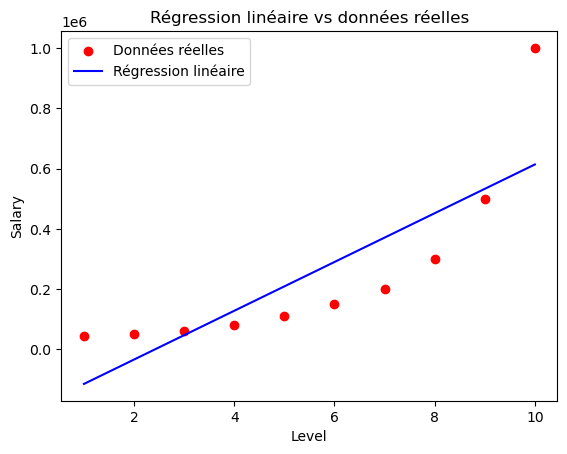

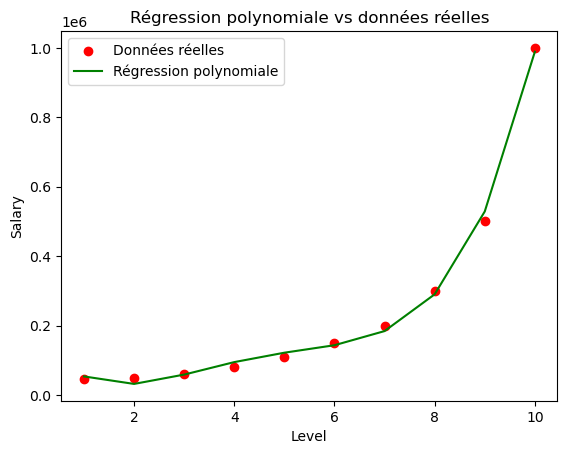

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# --- Régression linéaire ---
plt.scatter(X, y, color='red', label='Données réelles')
plt.plot(X, lr.predict(X), color='blue', label='Régression linéaire')
plt.title("Régression linéaire vs données réelles")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

# --- Régression polynomiale ---
# Pour une courbe plus lisse, on crée une grille de X
#X_grid = np.arange(min(X), max(X)+0.1, 0.1)  # pas 0.1 pour plus de points
#X_grid = X_grid.reshape((len(X_grid), 1))
X_grid=X

plt.scatter(X, y, color='red', label='Données réelles')
plt.plot(X_grid, lr_2.predict(pr.transform(X_grid)), color='green', label='Régression polynomiale')
plt.title("Régression polynomiale vs données réelles")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()


b) Soit un level égal à 7.5,  examinez quel salaire les modèles générés prédisent et à quel point ils ont précis. 

In [46]:
# Predict with linear regression
print(f'Linear Regression result : {lr.predict([[7.5]])}') 
# Predict with polynomial regression
print(f'Polynomial Regression result : {lr_2.predict(pr.fit_transform([[7.5]]))}') 

Linear Regression result : [411257.57575758]
Polynomial Regression result : [225126.29297787]


Données réelles jusqu’au Level = 5 → Salary = 110 000 $

Level = 7.5 → on peut estimer intuitivement que le salaire devrait être autour de 200 000 – 230 000

✅ La régression polynomiale est donc beaucoup plus précise

❌ La régression linéaire est trop haute car elle ne suit pas la courbe réelle

## IIIIIII. Régression logistique (classification des fleurs d’iris) 

In [50]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import datasets 
from sklearn.linear_model import LogisticRegression 
#chargement de base de données 
iris = datasets.load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

Le dataset  Iris se  compose  de  quatre  features ,  on n’utilisera que les deux premières features : Sepal_length et Sepal_width.

Dans le dataset Iris, target contient les classes suivantes :

0 → Iris Setosa

1 → Iris Versicolor

2 → Iris Virginica

Puisque la régression logistique est un algorithme de classification **binaire**, on va re-étiqueter les fleurs ayant le label 1 et 2 avec le label 1. Ainsi, on se retrouve avec un problème de classification binaire. 

In [55]:
# choix de deux variables : Utiliser les deux premières colonnes afin d'avoir un problème de classification binaire 
X = iris.data[:, :2] 
y = (iris.target != 0) * 1 # re-étiquetage des fleurs

print(X.shape)
print(y.shape)

(150, 2)
(150,)


X : les deux premières features

- Sepal_length

- Sepal_width

y : les étiquettes binaires

- 0 → Iris Setosa

- 1 → Iris Versicolor + Virginica(non setosa)


 #### RQ : **La ligne i de `X` correspond TOUJOURS à la ligne i de `y`.**

Ils sont **alignés index par index**.

 🔹 Exemple simplifié

### `X` (features)

| index | Sepal_length | Sepal_width |
| ----- | ------------ | ----------- |
| 0     | 5.1          | 3.5         |
| 1     | 4.9          | 3.0         |
| 2     | 6.2          | 3.4         |
| 3     | 5.9          | 3.0         |

#### `y` (labels)

| index | classe |
| ----- | ------ |
| 0     | 0      |
| 1     | 0      |
| 2     | 1      |
| 3     | 1      |

➡️ La fleur à l’index `0` :

* ses features sont `X[0] = [5.1, 3.5]`
* son label est `y[0] = 0`


#### 🔹 Ce que fait `y == 0`

Produit un **masque logique** :

```python
[True, True, False, False]
```

Cela signifie :

* index 0 → Setosa
* index 1 → Setosa
* index 2 → Non-Setosa
* index 3 → Non-Setosa


#### 🔹 Comment NumPy combine `X` et `y`

Quand tu écris :

```python
X[y == 0]
```

NumPy comprend :

> « Garde les lignes de X **aux mêmes indices** où `y == 0` est `True`. »

Donc :

```python
X[y == 0] = [
  [5.1, 3.5],
  [4.9, 3.0]
]
```


```python
X[y==0, 0]  # Sepal_length des Setosa(0)
X[y==0, 1]  # Sepal_width des Setosa(1)
```

#### 🎯 Pourquoi ça marche ?

Parce que :

* `X` et `y` ont **le même nombre de lignes** (150)
* chaque ligne représente **la même fleur**

📌 C’est une règle **fondamentale en machine learning**.





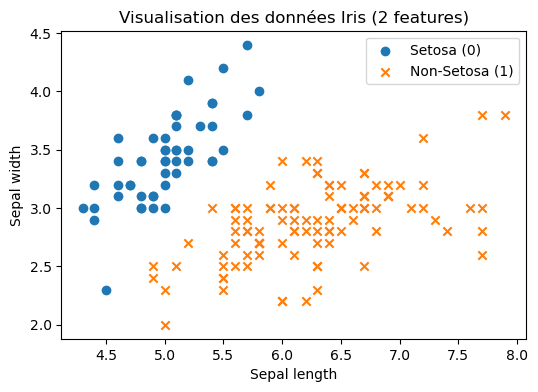

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Setosa (0)', marker='o')
plt.scatter(X[y==1, 0], X[y==1, 1], label='Non-Setosa (1)', marker='x')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.legend()
plt.title('Visualisation des données Iris (2 features)')
plt.show()


La visualisation montre que les fleurs Setosa sont facilement séparables des autres espèces à l’aide des deux premières caractéristiques. En revanche, les classes Versicolor et Virginica présentent un chevauchement important. Cela justifie le re-étiquetage et l’utilisation d’une régression logistique pour une classification binaire.

In [ ]:
## TRAIN 
model = LogisticRegression(C=1e20) # C est l’inverse de la régularisation.
model.fit(X, y) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+20
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
print(model.predict([[7, 3],[5.5, 2.5],[3,2],[5,3] ]) )



[1 1 0 0]


## IIIIIIII. Arbre de décision  

In [62]:
!pip install scikit-learn 
!pip install graphviz # ou conda install python-graphviz 
!pip install pydotplus 
!pip install six

26070.53s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable


26076.89s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 460.7 kB/s eta 0:00:00a 0:00:01


26084.14s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 764.7 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24552 sha256=e57f965eca4bca44d3b67b688efd96d14cbe4af9d81f4ae284372787ad06b79a
  Stored in directory: /home/amira/.cache/pip/wheels/77/54/7c/c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus


26092.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier  
from sklearn.model_selection import train_test_split  
from sklearn import metrics  
from sklearn.tree import export_graphviz 
from io import StringIO   
from IPython.display import Image   
import pydotplus 
import matplotlib.pyplot as plt 

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label'] 
diabetes_data = pd.read_csv("diabetes.csv", header=None, names=col_names)

#header=None : Cela veut dire : Le fichier n’a pas de ligne d’en-tête (Pandas considère que la première ligne contient des données, pas des noms)
#names : sert à donner des noms de colonnes



## Question 10

#### a) Dressez les graphes nécessaires pour mieux comprendre vos données.  


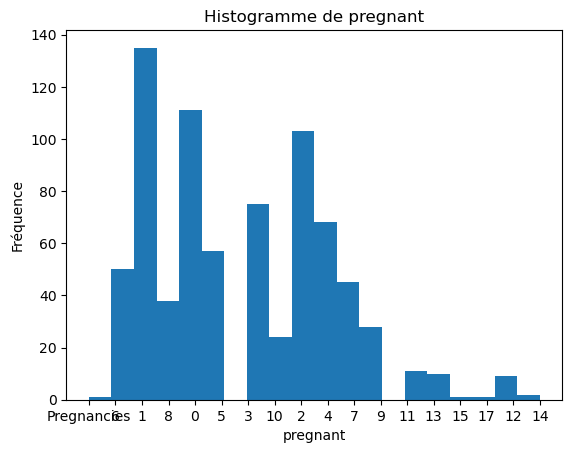

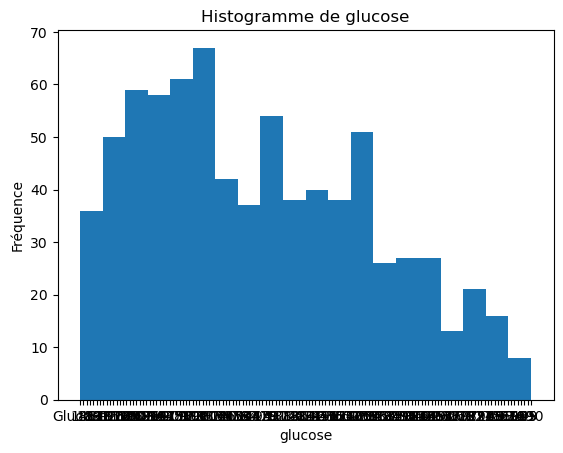

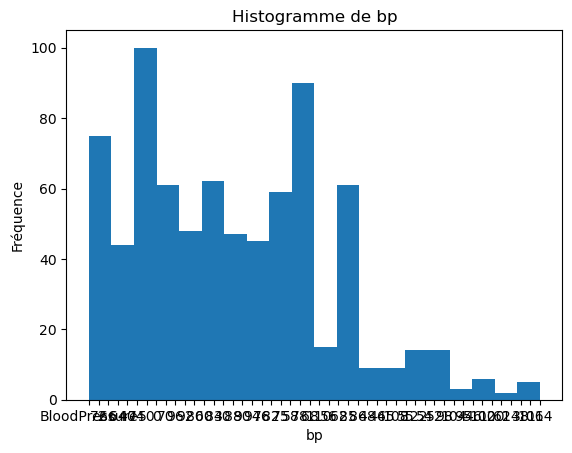

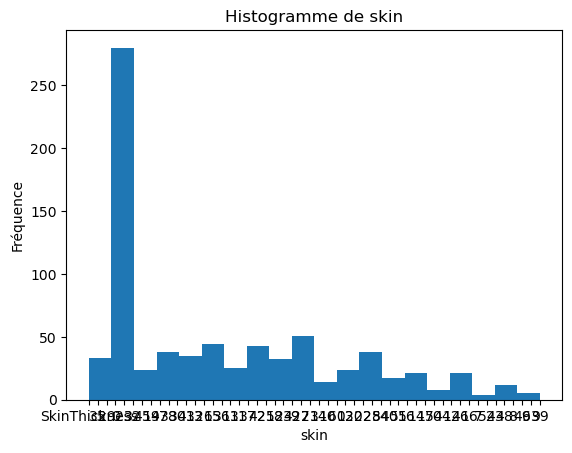

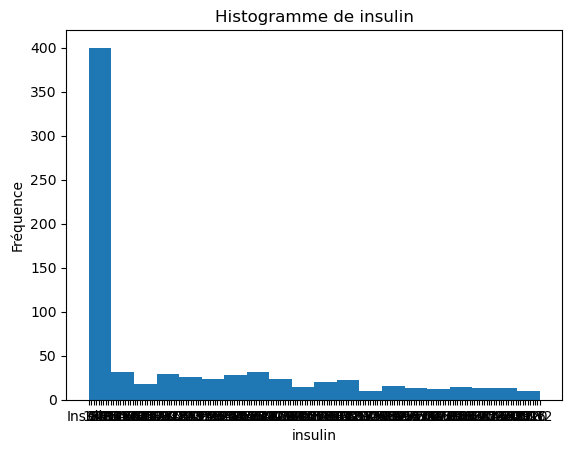

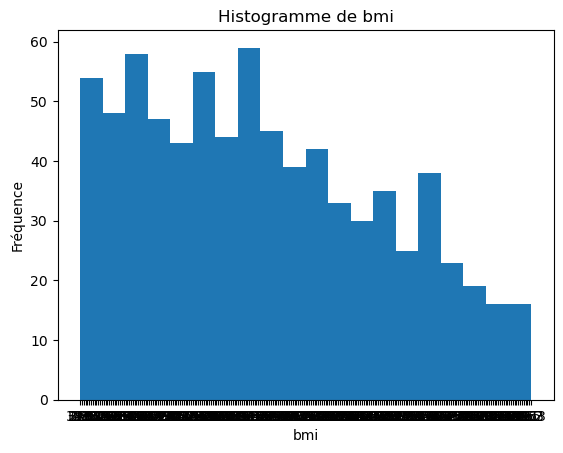

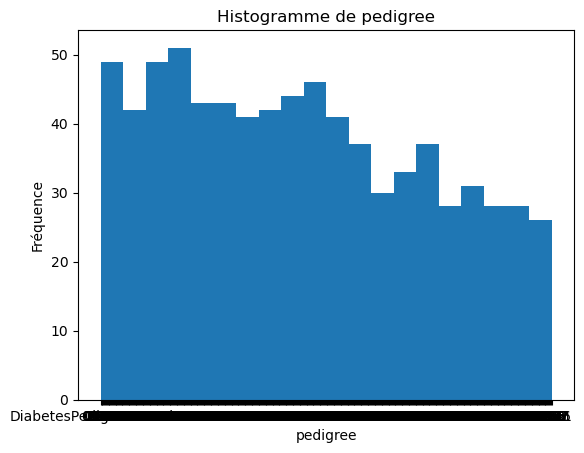

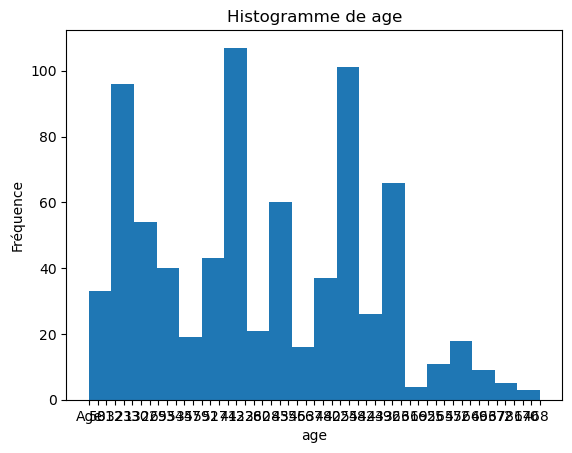

In [3]:
for col in col_names[:-1]:
    plt.figure()
    plt.hist(diabetes_data[col], bins=20)
    plt.title(f"Histogramme de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

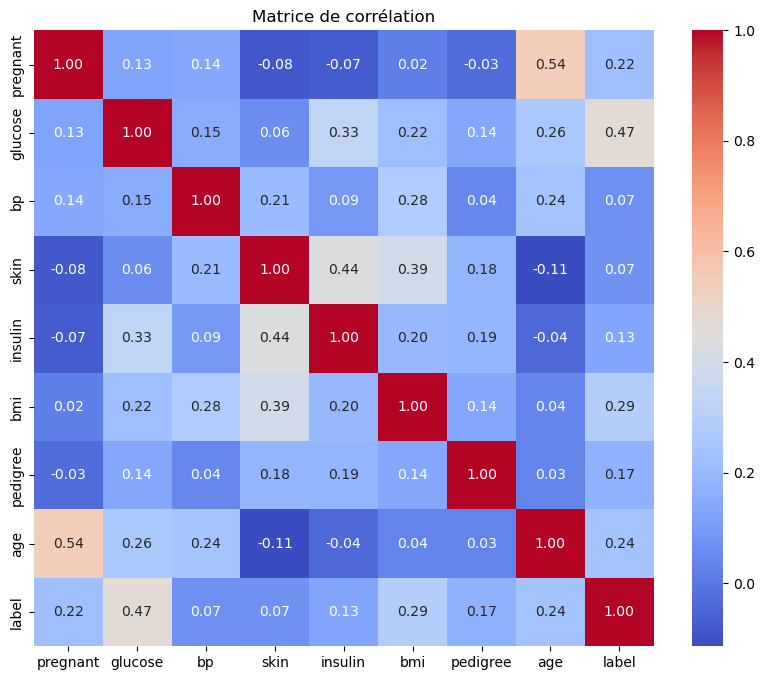

In [9]:
import seaborn as sns
for col in diabetes_data.columns:
    diabetes_data[col] = pd.to_numeric(diabetes_data[col], errors='coerce')
    
plt.figure(figsize=(10, 8))
correlation_matrix = diabetes_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

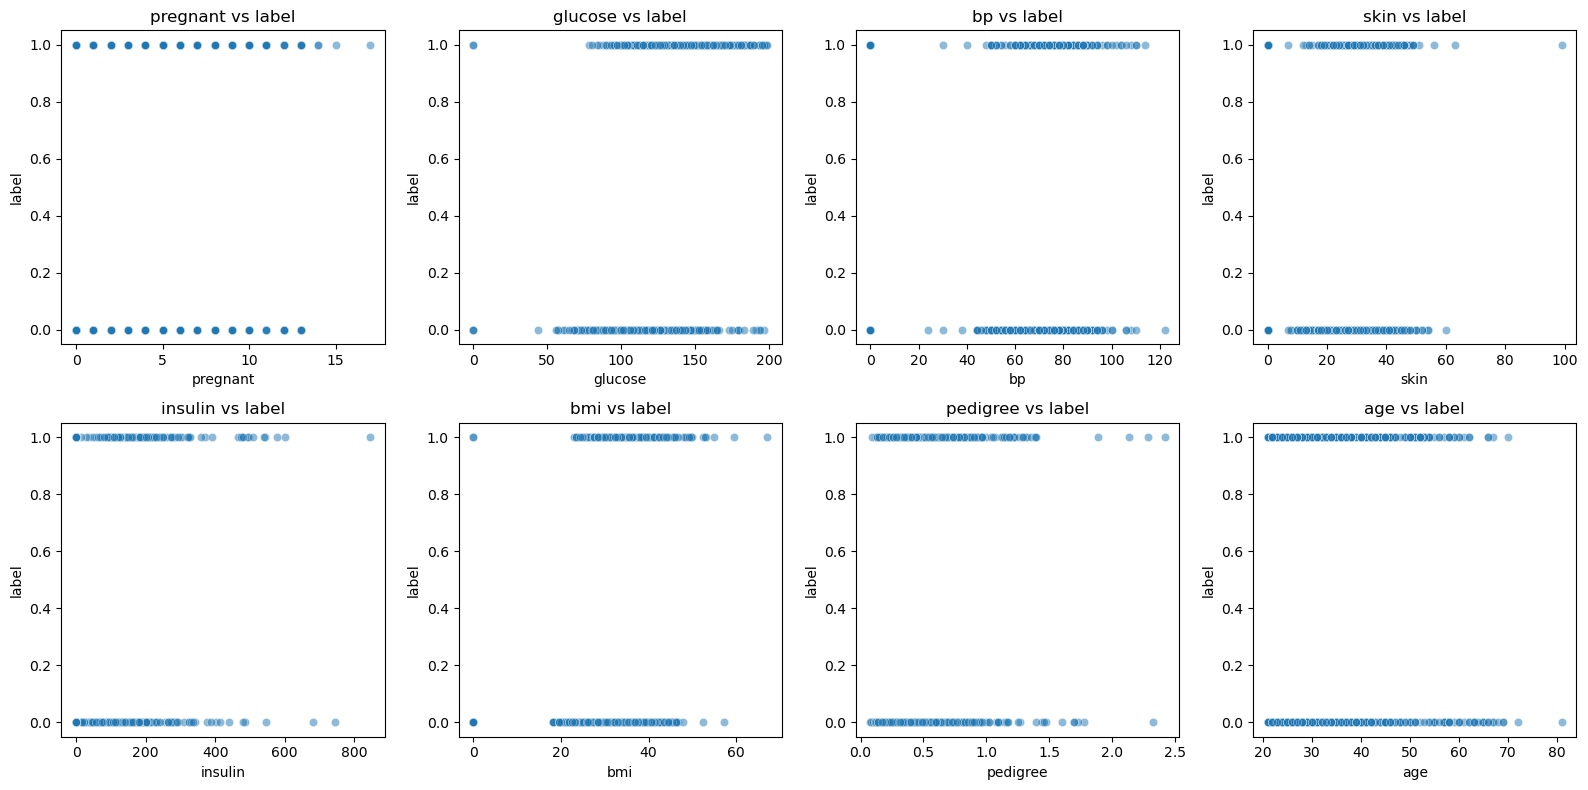

In [10]:
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(col_names[:-1]):
    sns.scatterplot(x=col, y='label', data=diabetes_data, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"{col} vs label")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("label")

plt.tight_layout()
plt.show()

#### b) Type du problème de classification

Il s'agit d'un problème de classification binaire.

Justification : La variable cible (label) ne possède que deux modalités possibles : 0 (test négatif pour le diabète) ou 1 (test positif pour le diabète). L'objectif est de prédire l'appartenance à l'une de ces deux classes.

## Question 11

#### a) divisez  l'ensemble  de  données  en  un  ensemble d'apprentissage   et   un   ensemble   de   test   

In [ ]:
from sklearn.model_selection import train_test_split

diabetes_data = diabetes_data.dropna()

# Variables explicatives
X = diabetes_data.drop('label', axis=1)

# Variable cible
y = diabetes_data['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y )  #stratify=y : Maintient la proportion diabétique / non diabétique

In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


#### b) Créez   un   modèle   d'arbre   de   décision   en   utilisant   la   fonction « DecisionTreeClassifier() » du package Scikit-learn qui fait recours à l’indice de Gini pour calculer l’impureté des nœuds.

In [17]:
# Create Decision Tree classifer object 
clf = DecisionTreeClassifier(criterion="gini", random_state=42) # gini par defaut ! 
# Train Decision Tree Classifer 
clf = clf.fit(X_train,y_train)
#Predict the response for test dataset 
y_pred = clf.predict(X_test)

## Question 12 : Evaluation

In [18]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.7272727272727273


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[85 15]
 [27 27]]


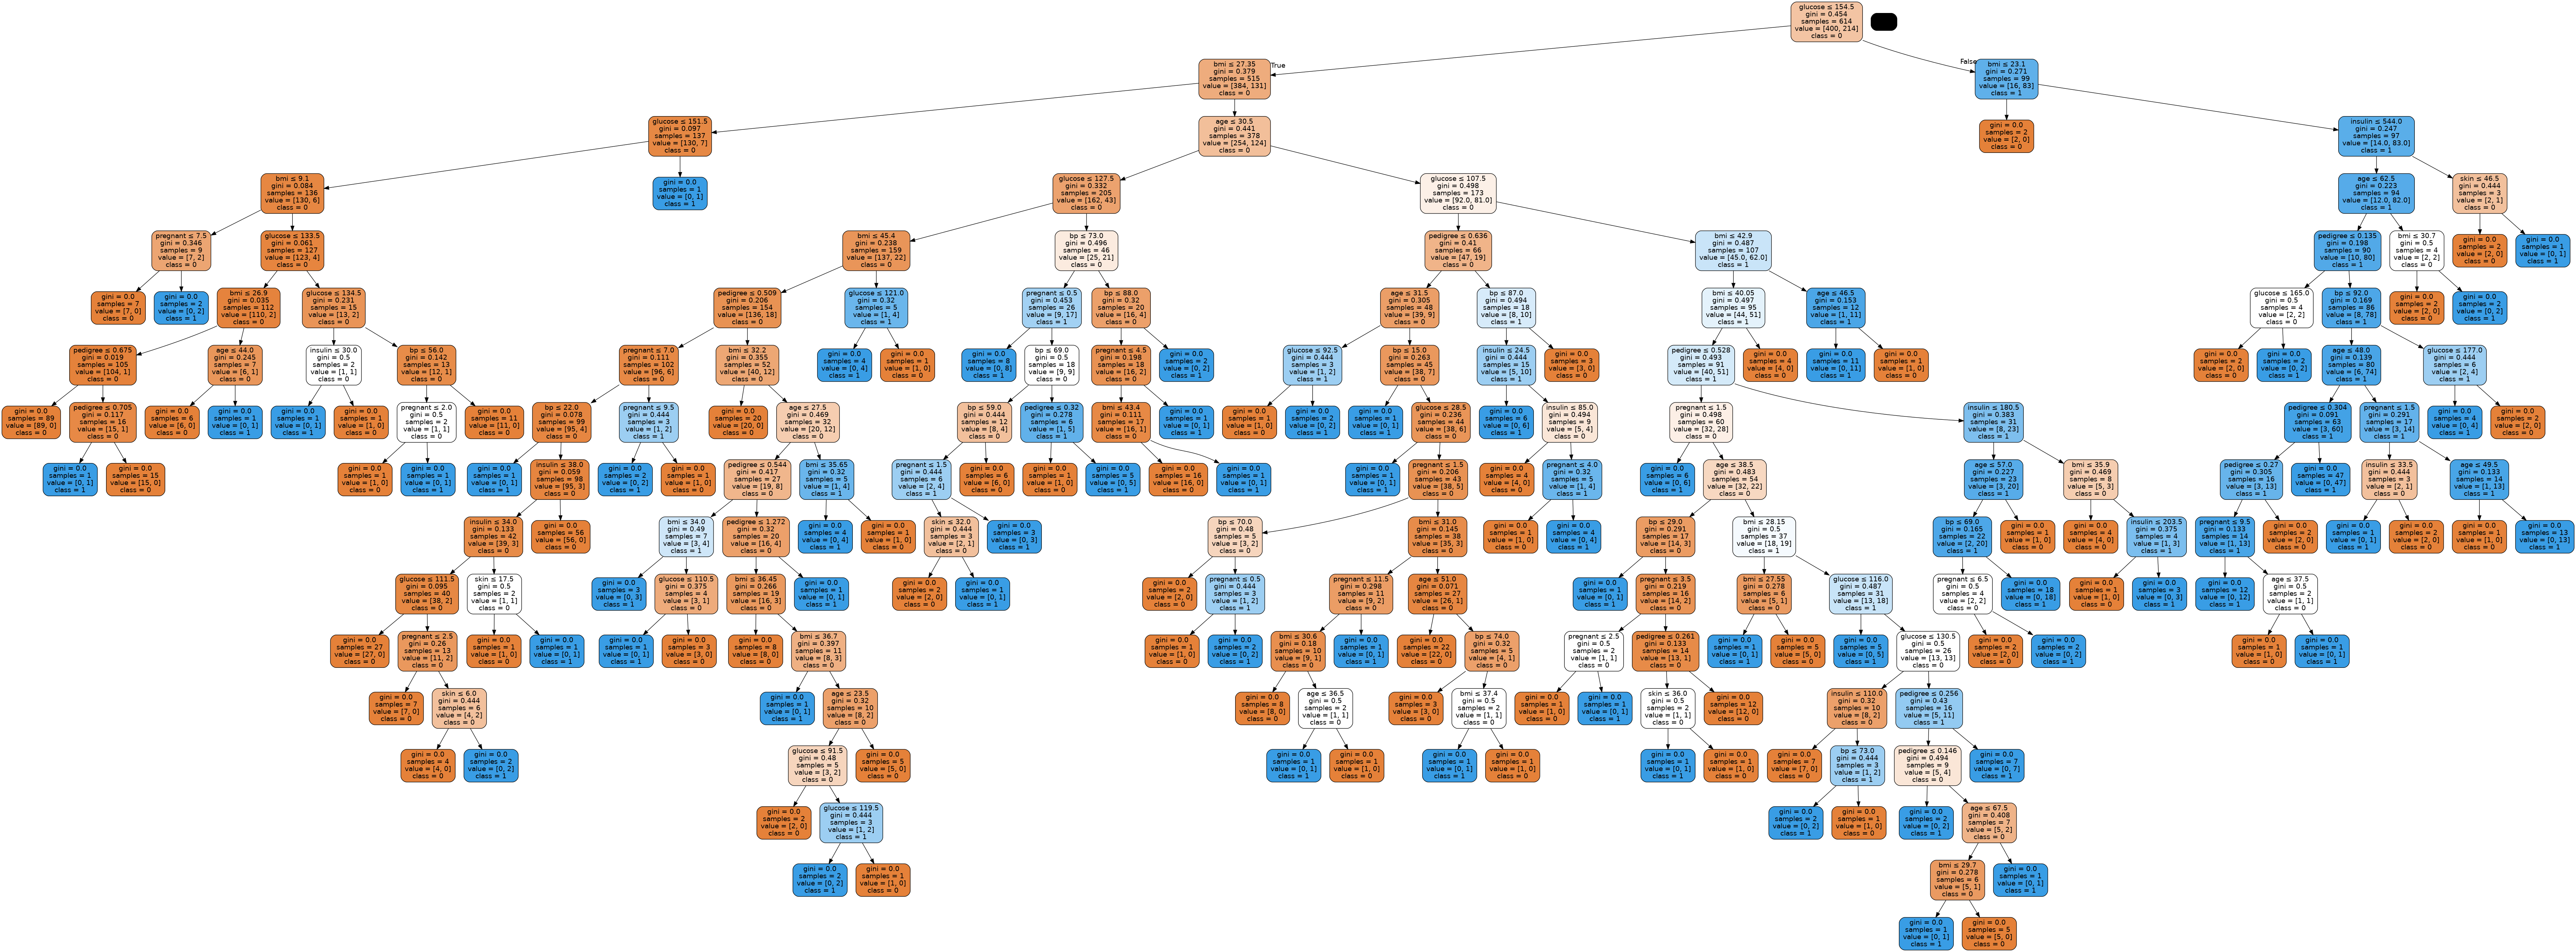

In [25]:
feature_cols = X.columns
dot_data = StringIO() 
export_graphviz(clf, out_file=dot_data,                   
                filled=True, rounded=True,                 
                special_characters=True,
                feature_names = feature_cols,
                class_names=['0','1']) 
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())   
graph.write_png('diabetes.png') 
Image(graph.create_png())


#### **2. `dot_data = StringIO()`**
- `StringIO()` crée un "fichier en mémoire" (buffer)

- Au lieu d'écrire dans un vrai fichier `.dot`, on écrit dans cette variable mémoire

- Plus rapide et ne nécessite pas de gestion de fichiers temporaires

#### **3. `export_graphviz(...)`**
Cette fonction exporte l'arbre de décision au format **DOT** (DOT = format texte qui décrit un graphique) :

- **`clf`** : ton modèle d'arbre de décision entraîné

- **`out_file=dot_data`** : écriture dans le buffer mémoire

- **`filled=True`** : remplit les nœuds avec des couleurs (utile pour visualiser)

- **`rounded=True`** : coins arrondis pour un rendu plus esthétique

- **`special_characters=True`** : support des caractères spéciaux

- **`feature_names=feature_cols`** : utilise les noms de colonnes comme étiquettes(au lieu de : X[1] <= 127.5 ? --> glucose <= 127.5 ? donc plus comprehensible)

- **`class_names=['0','1']`** : noms des classes (0=non diabétique, 1=diabétique)

#### **4. `graph = pydotplus.graph_from_dot_data(dot_data.getvalue())`**

- Récupère le contenu DOT du buffer (`dot_data.getvalue()`)

- `pydotplus` transforme ce texte DOT en un objet graphique manipulable

#### **5. `graph.write_png('diabetes.png')`**

- Sauvegarde l'arbre dans un fichier image PNG nommé `'diabetes.png'`


#### **6. `Image(graph.create_png())`**
- `graph.create_png()` génère l'image PNG en mémoire

- `Image()` l'affiche directement dans Jupyter Notebook/IPython

---

#### **Que verras-tu dans l'image générée ?**

Un arbre avec :
1. **Nœuds de décision** (rectangles) :
   - `feature <= valeur` : condition de décision
   - `gini` : impureté de Gini (mesure de mélange des classes)
   - `samples` : nombre d'échantillons dans ce nœud
   - `value` : [nb_class0, nb_class1]
   - `class` : classe prédite(majoritaire)

2. **Nœuds feuilles** (terminaux) :
   - Donnent la prédiction finale

3. **Couleurs** :
   - Nuances représentent la "pureté" de la classe
   - Souvent : bleu pour classe 0, orange pour classe 1

---

#### **Exemple de nœud :**
```
glucose <= 127.5
gini = 0.32
samples = 537
value = [350, 187]
class = 0
```

Signification :
- Condition : si glucose ≤ 127.5
- Impureté Gini = 0.32 (0 = pur, 0.5 = mélangé)
- 537 échantillons arrivent ici
- 350 sont de classe 0, 187 de classe 1
- Classe prédite : 0 (majoritaire)

---


#### a) Quelles informations sont affichées au niveau de chaque nœud ?

##### 1 La condition de séparation (split)

Exemple :

```text
glucose <= 127.5
```

##### 2 L’indice de Gini

Il mesure l’**impureté du nœud** :

* `gini = 0` → nœud pur (une seule classe)
* plus gini est élevé → plus le mélange des classes est important

##### 3 Le nombre d’échantillons

Exemple :

```text
samples = 614
```

Nombre d’observations qui arrivent à ce nœud.


##### 4 La distribution des classes

Exemple :

```text
value = [400, 214]
```

--> Nombre d’exemples :

* classe 0 (non diabétique)
* classe 1 (diabétique)


##### 5 La classe prédite

Exemple :

```text
class = 0
```

--> Classe majoritaire dans le nœud (prédiction finale).


##### 6 Couleur du nœud 

* **Bleu** → classe 0
* **Orange** → classe 1
* Plus la couleur est foncée → plus le nœud est pur



#### b) L’arbre affiché est-il élagué ?

Non, l’arbre n’est PAS élagué

Parce qu'on a créé ton modèle ainsi :

```python
clf = DecisionTreeClassifier()
```

Sans paramètres de limitation :

* `max_depth`
* `min_samples_split`
* `min_samples_leaf`
* `max_leaf_nodes`

--> L’arbre est **entièrement développé** jusqu’à :

* atteindre des nœuds presque purs
* ou ne plus pouvoir séparer les données



##### Conséquence

* Arbre **très profond**
* **Risque de sur-apprentissage (overfitting)**



## Question 14

Pour optimiser la performance des arbres de décision, il est possible de modifier les paramètre de la fonction « DecisionTreeClassifier() » 
* **critère** : Le critère sert à répondre à cette question à chaque nœud : “Comment séparer les données pour que les groupes soient le plus purs possible ?”

(par défaut=”gini”) « gini » pour l'indice de Gini et « entropie » pour le gain d'information. 

* **splitter** : **Comment l’arbre choisit la séparation (le split) à chaque nœud ?**

`"best"` (par defaut):

* Il **teste toutes les séparations possibles**
* Il calcule le critère (gini ou entropie)
* Il choisit **la meilleure séparation possible**

--> Plus précis mais Plus lent

 `"random"` :

* Il teste **quelques séparations au hasard**
* Puis il choisit la meilleure **parmi celles testées**

-->Plus rapide mais Moins précis

Exemple :

> Il teste au hasard “age ≤ 40” et “bmi ≤ 30”
> Il garde la meilleure des deux

* **max_degree**  :  (par  défaut=Aucun).  permet  de  définir  la  profondeur maximale d'un arbre. 

Si « aucun » est défini, les nœuds sont développés jusqu'à ce que toutes les feuilles contiennent moins d'échantillons que **min_samples_split**. 

Une valeur plus élevée de la profondeur maximale provoque unover-fittingt, et une valeur inférieure entraîne un under-fitting.

#### a) Arbre de décision avec entropie(Shanon) et profondeur maximale = 3

In [26]:
from sklearn.tree import DecisionTreeClassifier

clf_opt = DecisionTreeClassifier(
    criterion="entropy",   # gain d'information
    splitter="best",
    max_depth=3,
    random_state=42
)

clf_opt.fit(X_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### b) Génération du graphique de l’arbre optimisé

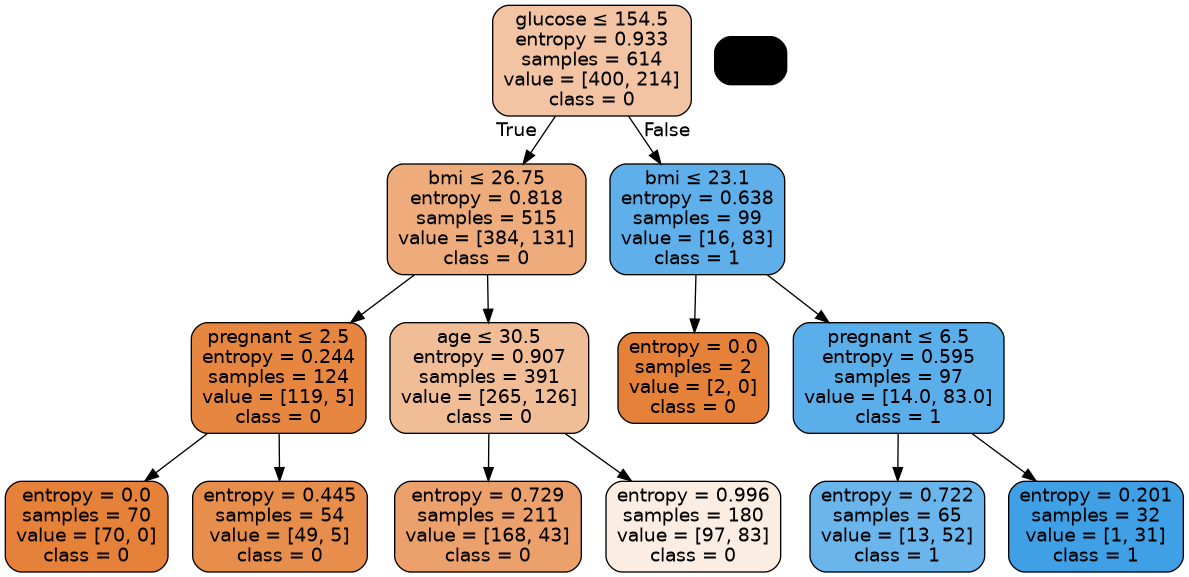

In [27]:
from sklearn.tree import export_graphviz
from io import StringIO
import pydotplus
from IPython.display import Image

dot_data = StringIO()

export_graphviz(
    clf_opt,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=feature_cols,
    class_names=['0', '1']
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())


#### c) Cette optimisation est-elle un pré-élagage ou un post-élagage ?
il s'agit de Pré-élagage parce que :

la profondeur maximale (max_depth=3) est fixée avant l’entraînement

--> l’arbre est empêché de grandir dès le départ

--> On bloque la croissance de l’arbre pendant sa construction.

Post-élagage : 

L’arbre est d’abord construit complètement , Puis on coupe des branches après